In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
df = pd.read_csv('ChMBL_TgDHFR.csv', delimiter=';')
df.head(2)

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value
0,CHEMBL66077,NaN,NaN,226.24,0.0,1.18,18,Nc1nc(N)c2[nH]c(-c3ccccc3)nc2n1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1156926,1,Scientific Literature,Bioorg Med Chem,2010,NaN,NaN,NaN,NaN
1,CHEMBL22623,NaN,NaN,354.41,0.0,2.15,3b,COc1cc(OC)cc(N(C)Cc2cnc3nc(N)nc(N)c3c2C)c1,IC50,'=',...,SINGLE PROTEIN,CHEMBL1128680,1,Scientific Literature,J Med Chem,1995,NaN,NaN,NaN,NaN


In [4]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1637 entries, 0 to 1636
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          1637 non-null   object 
 1   Molecule Name               181 non-null    object 
 2   Molecule Max Phase          180 non-null    float64
 3   Molecular Weight            1637 non-null   float64
 4   #RO5 Violations             1636 non-null   float64
 5   AlogP                       1636 non-null   float64
 6   Compound Key                1637 non-null   object 
 7   Smiles                      1637 non-null   object 
 8   Standard Type               1637 non-null   object 
 9   Standard Relation           1612 non-null   object 
 10  Standard Value              1612 non-null   float64
 11  Standard Units              1610 non-null   object 
 12  pChEMBL Value               1444 non-null   float64
 13  Data Validity Comment       38 no

In [10]:
df['Standard Units'].value_counts()

Standard Units
nM    1549
%       44
uM      17
Name: count, dtype: int64

In [11]:
df['Standard Type'].value_counts()

Standard Type
IC50             1560
Inhibition         44
Activity           27
Relative IC50       3
Ki                  3
Name: count, dtype: int64

In [3]:
df['Ligand Efficiency LE'].head()

0    0.37
1    0.38
2    0.26
3    0.29
4    0.40
Name: Ligand Efficiency LE, dtype: float64

In [15]:
df[['pChEMBL Value','Standard Value']].head()

,pChEMBL Value,Standard Value
0,4.55,28183.83
1,7.24,58.00
2,5.35,4500.00
3,5.28,5300.00
4,6.80,160.00


In [3]:
df['Smiles'].nunique()

788

In [38]:
# Grouping by 'Smiles' and showing 'Standard Value' for each group
grouped = df_ic50.groupby('Smiles')['Standard Value'].apply(list)

# Displaying the first few groups and their 'Standard Value' lists
print(grouped.head())

Smiles
C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1                                          [12.0, 12.0, 12.0]
C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc1         [18.0, 220.0, 430.0, 430.0, 220.0]
C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)N[C@@H](CCC(=O)O)C(=O)O)cc1           [220.0, 72.0, 260.0, 430.0]
C#CCN(Cc1ccc2nc(N)nc(N)c2n1)c1ccc(C(=O)C(F)(F)F)cc1                                                   [54.0]
C#CCN(Cc1ccc2nc(N)nc(N)c2n1)c1ccc(C(C)=O)cc1                                                          [20.0]
Name: Standard Value, dtype: object


In [40]:
# Filter the DataFrame for the specified SMILES value
filtered_df = df_ic50[df_ic50['Smiles'] == 'C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(CCC(=O)O)C(=O)O)cc1']

# Transpose the DataFrame
transposed_df = filtered_df.transpose()

# Display the transposed DataFrame
transposed_df

,195,440,534,680,1423
Molecule ChEMBL ID,CHEMBL422395,CHEMBL422395,CHEMBL422395,CHEMBL422395,CHEMBL422395
Molecule Name,NaN,NaN,NaN,NaN,NaN
Molecule Max Phase,NaN,NaN,NaN,NaN,NaN
Molecular Weight,477.48,477.48,477.48,477.48,477.48
#RO5 Violations,0.0,0.0,0.0,0.0,0.0
AlogP,1.19,1.19,1.19,1.19,1.19
Compound Key,PDDF,PDDF,PDDF,PDDF,PDDF
Smiles,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...
Standard Type,IC50,IC50,IC50,IC50,IC50
Standard Relation,'=','=','=','=','='


# 1. Data Cleaning:

## 1.1. Rows with IC50 nM only:

In [16]:
df_ic50 = df[df['Standard Type']=='IC50']
df_ic50.shape

(1560, 47)

In [17]:
df_ic50['Standard Units'].value_counts()

Standard Units
nM    1546
Name: count, dtype: int64

In [18]:
df_ic50 = df_ic50.dropna(subset=['Standard Units'])
df_ic50.shape

(1546, 47)

## 1.2. Dublicates:

In [37]:
df_ic50['Smiles'].nunique()

758

In [41]:
# Checking duplicates:
# Identify rows with identical values in both 'Ligand SMILES' and 'BindingDB Target Chain Sequence'
df_dupl = df_ic50[df_ic50.duplicated(subset=['Smiles'], keep=False)]

# Show the duplicates
df_dupl.shape

(1114, 48)

In [42]:
# Group by 'PubChem CID' and then display the 'pH' and 'IC50 (nM)' for each group
grouped_dupl = df_dupl.groupby('Smiles')[['Molecule ChEMBL ID','Standard Value','pIC50 Value']]

# Convert to a list for display or further processing
grouped_dupl_list = grouped_dupl.apply(lambda x: x.reset_index(drop=True)).reset_index()

# Display the result
grouped_dupl_list.head()

,Smiles,level_1,Molecule ChEMBL ID,Standard Value,pIC50 Value
0,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,0,CHEMBL120821,12.0,7.920819
1,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,1,CHEMBL120821,12.0,7.920819
2,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,2,CHEMBL120821,12.0,7.920819
3,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,0,CHEMBL422395,18.0,7.744727
4,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,1,CHEMBL422395,220.0,6.657577


### Step 1: Remove Outliers

In [46]:
import pandas as pd

# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply the outlier removal function to each group
grouped_dupl_list_no_outliers = grouped_dupl_list.groupby('Smiles').apply(lambda group: remove_outliers_iqr(group, 'Standard Value')).reset_index(drop=True)

# Display the cleaned DataFrame without outliers
grouped_dupl_list_no_outliers.head(10)


,Smiles,level_1,Molecule ChEMBL ID,Standard Value,pIC50 Value
0,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,0,CHEMBL120821,12.0,7.920819
1,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,1,CHEMBL120821,12.0,7.920819
2,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,2,CHEMBL120821,12.0,7.920819
3,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,0,CHEMBL422395,18.0,7.744727
4,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,1,CHEMBL422395,220.0,6.657577
5,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,2,CHEMBL422395,430.0,6.366532
6,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,3,CHEMBL422395,430.0,6.366532
7,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,4,CHEMBL422395,220.0,6.657577
8,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)N[C...,0,CHEMBL389051,220.0,6.657577
9,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)N[C...,1,CHEMBL389051,72.0,7.142668


### Step 2: Calculate Average IC50:

In [53]:
# Calculate the average of log_IC50 for each group in grouped_dupl_tg_list_no_outliers
average_ic50_df = grouped_dupl_list_no_outliers.groupby(['Smiles'], as_index=False)['Standard Value'].mean()

# Rename the column for clarity
average_ic50_df.rename(columns={'Standard Value': 'Standard Value Avg'}, inplace=True)

# Display the resulting DataFrame with BindingDB Target Chain Sequence, Ligand SMILES, and their average log_IC50 values
average_ic50_df

,Smiles,Standard Value Avg
0,C#CCN(CC1CCc2nc(N)nc(N)c2C1)c1cc(OC)c(OC)c(OC)c1,12.00
1,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)NC(...,263.60
2,C#CCN(Cc1ccc2[nH]c(N)nc(=O)c2c1)c1ccc(C(=O)N[C...,245.50
3,C#CCN(Cc1cnc2nc(N)nc(N)c2c1C)c1cc(OC)c(OC)c(OC)c1,7.70
4,CC(C)c1c(Sc2c(Cl)cccc2Cl)[nH]c2nc(N)nc(N)c12,1360.00
...,...,...
321,Nc1nc2c(c(Nc3cccc(Br)c3)n1)-c1ccccc1C2,13000.00
322,Nc1nc2sc3cccc(CNc4ccc(C(=O)N[C@@H](CCC(=O)O)C(...,80.00
323,Nc1nc2sc3cccc(CNc4ccc5c(c4)CN([C@@H](CCC(=O)O)...,90.00
324,Nc1ncc(N2CCN(c3cccc(-c4ccccc4)c3)CC2)c(N)n1,8.73


In [54]:
# Remove duplicates based on 'Ligand SMILES' and 'BindingDB Target Chain Sequence'
# Keep the first occurrence and drop the rest
df_ic50_cleaned = df_ic50.drop_duplicates(subset=['Smiles'], keep='first')

# Display the cleaned DataFrame
df_ic50_cleaned.shape


(758, 48)

In [55]:
df_ic50_cleaned.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,pIC50 Value
0,CHEMBL66077,NaN,NaN,226.24,0.0,1.18,18,Nc1nc(N)c2[nH]c(-c3ccccc3)nc2n1,IC50,'=',...,CHEMBL1156926,1,Scientific Literature,Bioorg Med Chem,2010,NaN,NaN,NaN,NaN,4.550000
1,CHEMBL22623,NaN,NaN,354.41,0.0,2.15,3b,COc1cc(OC)cc(N(C)Cc2cnc3nc(N)nc(N)c3c2C)c1,IC50,'=',...,CHEMBL1128680,1,Scientific Literature,J Med Chem,1995,NaN,NaN,NaN,NaN,7.236572
2,CHEMBL601520,NaN,NaN,372.43,0.0,4.13,49,CCn1c2ccccc2c2cc(NCc3coc4nc(N)nc(N)c34)ccc21,IC50,'=',...,CHEMBL1156926,1,Scientific Literature,Bioorg Med Chem,2010,NaN,NaN,NaN,NaN,5.346787
3,CHEMBL69363,NaN,NaN,342.40,0.0,2.53,7,CCOc1ccc(OCC)c(NCc2c[nH]c3nc(N)nc(N)c23)c1,IC50,'=',...,CHEMBL1156926,1,Scientific Literature,Bioorg Med Chem,2010,NaN,NaN,NaN,NaN,5.275724
4,CHEMBL609914,NaN,NaN,325.44,0.0,3.46,59,Cc1c(Sc2cccc3c2CCCC3)[nH]c2nc(N)nc(N)c12,IC50,'=',...,CHEMBL1156926,1,Scientific Literature,Bioorg Med Chem,2010,NaN,NaN,NaN,NaN,6.795880


### Step 3: Substitute IC50 values in duplicated cases to average


In [56]:
# Merge the two dataframes on the 'BindingDB Target Chain Sequence' and 'Ligand SMILES' columns
df_ic50_cleaned = df_ic50_cleaned.merge(
    average_ic50_df,
    on=['Smiles'],
    how='left'
)

# Substitute the 'log_IC50' values in merged_df_cleaned with 'Average log_IC50' where available
df_ic50_cleaned['Standard Value'] = df_ic50_cleaned['Standard Value Avg'].combine_first(df_ic50_cleaned['Standard Value'])

# Drop the 'Average log_IC50' column as it's no longer needed
df_ic50_cleaned = df_ic50_cleaned.drop(columns=['Standard Value Avg'])

# Display the updated DataFrame
df_ic50_cleaned[['Smiles', 'Standard Value']].head(10)


,Smiles,Standard Value
0,Nc1nc(N)c2[nH]c(-c3ccccc3)nc2n1,28061.276667
1,COc1cc(OC)cc(N(C)Cc2cnc3nc(N)nc(N)c3c2C)c1,57.980000
2,CCn1c2ccccc2c2cc(NCc3coc4nc(N)nc(N)c34)ccc21,4483.420000
3,CCOc1ccc(OCC)c(NCc2c[nH]c3nc(N)nc(N)c23)c1,5282.690000
4,Cc1c(Sc2cccc3c2CCCC3)[nH]c2nc(N)nc(N)c12,159.245000
5,COc1cccc(SCc2cnc3nc(N)nc(N)c3c2C)c1,110.000000
6,CCN(Cc1ccc2ccccc2c1)c1ccc2nc(N)nc(N)c2c1,12.000000
7,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2724.516129
8,COc1cc(N(C=O)Cc2cnc3nc(N)nc(N)c3c2)cc(OC)c1OC,1099.670000
9,COc1ccc(CNc2cnc3nc(N)nc(N)c3c2)cc1OC,729.986667


## 1.2. Converting IC50 nM to pIC50

In [19]:
df_ic50_cleaned['Standard Value'].max()

27600000.0

In [20]:
# Check if any values are greater than 100,000,000
mask = df_ic50_cleaned['Standard Value'] > 100000000

# Substitute values greater than 100,000,000 with 100,000,000
df_ic50_cleaned.loc[mask, 'Standard Value'] = 100000000

In [21]:
df_ic50_cleaned['Standard Value'].max()

27600000.0

In [57]:
# Convert values from nanomolar to molar and take the log10
df_ic50_cleaned['pIC50 Value'] = -np.log10(df_ic50_cleaned['Standard Value'] / 1e9)

df_ic50_cleaned[['Standard Value','pIC50 Value','pChEMBL Value']].head(4)

,Standard Value,pIC50 Value,pChEMBL Value
0,28061.276667,4.551893,4.55
1,57.980000,7.236722,7.24
2,4483.420000,5.348391,5.35
3,5282.690000,5.277145,5.28


<Axes: >

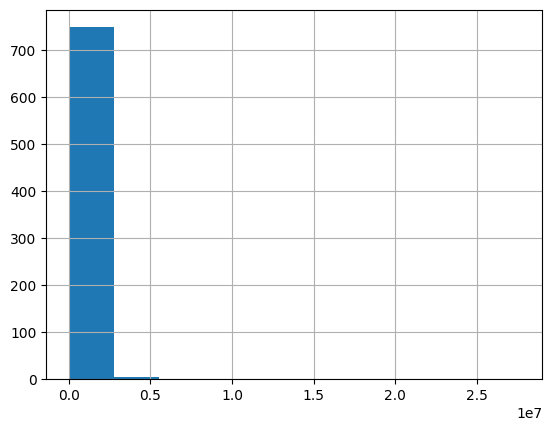

In [58]:
df_ic50_cleaned['Standard Value'].hist()

<Axes: >

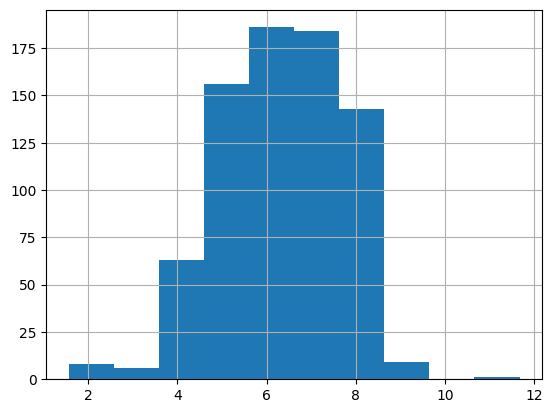

In [59]:
df_ic50_cleaned['pIC50 Value'].hist()

## 1.3. Column Selection

In [60]:
df_ic50_clean = df_ic50_cleaned[['Molecule ChEMBL ID','Smiles','Molecular Weight','AlogP','Standard Value','pIC50 Value']]
df_ic50_clean.shape

(758, 6)

In [61]:
#Reset index:
df_ic50_clean = df_ic50_clean.reset_index(drop=True)

In [63]:
#Save db to csv file
df_ic50_clean.to_csv('df_ic50_clean.csv', index = False)

# 2. Duplicates by CID:

In [1]:
import pandas as pd

df = pd.read_csv('df_ic50_clean.csv')
df.head(2)

,Molecule ChEMBL ID,Smiles,Molecular Weight,AlogP,Standard Value,pIC50 Value
0,CHEMBL66077,Nc1nc(N)c2[nH]c(-c3ccccc3)nc2n1,226.24,1.18,28061.276667,4.551893
1,CHEMBL22623,COc1cc(OC)cc(N(C)Cc2cnc3nc(N)nc(N)c3c2C)c1,354.41,2.15,57.980000,7.236722


In [2]:
df.shape

(758, 6)

In [3]:
df['Molecule ChEMBL ID'].nunique()

758

## 2.1. Function to get PubChem CID from SMILES

In [4]:
import requests
import pandas as pd

# Function to get PubChem CID from SMILES
def get_pubchem_cid_from_smiles(smiles):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{smiles}/cids/JSON"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        if 'IdentifierList' in data and 'CID' in data['IdentifierList']:
            return data['IdentifierList']['CID'][0]  # Return the first CID found
        else:
            return "No CID found"
    else:
        return f"Error: Unable to fetch data, status code {response.status_code}"

# Apply the function to the DataFrame to get PubChem CIDs
df['cid'] = df['Smiles'].apply(get_pubchem_cid_from_smiles)

# Display the DataFrame with the new PubChem CID column
df[['cid','Smiles']].head()

,cid,Smiles
0,99545,Nc1nc(N)c2[nH]c(-c3ccccc3)nc2n1
1,382165,COc1cc(OC)cc(N(C)Cc2cnc3nc(N)nc(N)c3c2C)c1
2,481448,CCn1c2ccccc2c2cc(NCc3coc4nc(N)nc(N)c34)ccc21
3,10450058,CCOc1ccc(OCC)c(NCc2c[nH]c3nc(N)nc(N)c23)c1
4,46233684,Cc1c(Sc2cccc3c2CCCC3)[nH]c2nc(N)nc(N)c12


In [6]:
df['cid'].value_counts()

cid
Error: Unable to fetch data, status code 400    81
99545                                            1
456430                                           1
46233489                                         1
481453                                           1
                                                ..
25218337                                         1
134136557                                        1
134152596                                        1
11339680                                         1
155528338                                        1
Name: count, Length: 678, dtype: int64

In [7]:
df[df['cid']=='Error: Unable to fetch data, status code 400']

,Molecule ChEMBL ID,Smiles,Molecular Weight,AlogP,Standard Value,pIC50 Value,cid
45,CHEMBL87423,CCc1nc(N)nc(N)c1-c1ccc(Cl)c(/N=N/N(CCOC(C)=O)C...,535.96,5.61,2540.000000,5.595166,"Error: Unable to fetch data, status code 400"
50,CHEMBL221172,COc1cc(C(O)C#Cc2c(C)nc(N)nc2N)cc(OC)c1OC,344.37,1.06,9100.000000,5.040959,"Error: Unable to fetch data, status code 400"
51,CHEMBL219624,COc1cc(CC#Cc2cnc(N)nc2N)cc(OC)c1OC,314.35,1.26,21700.000000,4.663540,"Error: Unable to fetch data, status code 400"
54,CHEMBL145005,COc1ccc(/C=C/c2cnc3nc(N)nc(N)c3c2)cc1,293.33,2.37,1499.893333,5.823940,"Error: Unable to fetch data, status code 400"
78,CHEMBL313131,CCc1nc(N)nc(N)c1-c1ccc(Cl)c(/N=N/N(CCOC(C)=O)C...,481.99,4.90,830.000000,6.080922,"Error: Unable to fetch data, status code 400"
...,...,...,...,...,...,...,...
701,CHEMBL35020,COc1ccc(C#Cc2cccc(C(=O)O)c2)cc1Cc1cnc(N)nc1N,374.40,2.34,5.500000,8.259637,"Error: Unable to fetch data, status code 400"
703,CHEMBL187595,COc1ccc(C#CCCCC(=O)O)c(Cc2cnc3nc(N)nc(N)c3c2C)c1,405.46,2.70,5.800000,8.236572,"Error: Unable to fetch data, status code 400"
706,CHEMBL313440,CCc1nc(N)nc(N)c1-c1ccc(Cl)c(/N=N/N(CCOC(C)=O)C...,497.99,4.60,440.000000,6.356547,"Error: Unable to fetch data, status code 400"
719,CHEMBL34641,COc1ccc(/C=C/COc2ccccc2C(=O)O)cc1Cc1cnc(N)nc1N,406.44,3.03,2500.000000,5.602060,"Error: Unable to fetch data, status code 400"


In [8]:
#Save db to csv file
df.to_csv('V2-df_ic50_chmbl_CID.csv', index = False)

## 2.2. Fill Error CID by hands

In [1]:
import pandas as pd

df_3 = pd.read_csv('V2-df_ic50_chmbl_CID_myFill.csv')
df_3.head(2)

,Molecule ChEMBL ID,Smiles,Molecular Weight,AlogP,Standard Value,pIC50 Value,cid
0,CHEMBL85576,CCc1nc(N)nc(N)c1-c1ccc(Cl)c(/N=N/N(CCOC(=O)C(C...,496.02,5.22,660.000000,6.180456,11071072
1,CHEMBL141708,COc1ccc(/C=C/c2cnc3nc(N)nc(N)c3c2)cc1OC,323.36,2.38,1399.863333,5.853914,6474985


In [10]:
df_3['cid'].nunique()

758

In [2]:
df_3[df_3['cid']==4993]

,Molecule ChEMBL ID,Smiles,Molecular Weight,AlogP,Standard Value,pIC50 Value,cid
756,CHEMBL36,CCc1nc(N)nc(N)c1-c1ccc(Cl)cc1,248.72,2.52,314.083333,6.502955,4993
